In [1]:
import sys
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import koreanize_matplotlib

sys.path.append('C:/dev/project/SKN27-2nd-4TEAM')

from src.seed import set_seed                                              # ← 추가
from src.pipeline.missing_value import CJ_MissingValue, JH_train_stats, JH_MissingValue
from src.pipeline.outlier_control import OutlierControl
from src.pipeline.features import FeatureCreate

# 시드 고정
set_seed(42)  # ← 추가

In [2]:
# ── 1. 데이터 로드 ──────────────────────────────
df = pd.read_excel('C:/dev/project/SKN27-2nd-4TEAM/data/dataset.xlsx', sheet_name='E Comm')
df = df.drop(columns=['CustomerID'])  # ID 컬럼 제거

# ── 2. Train/Test 분리 ──────────────────────────
X = df.drop(columns=['Churn'])
y = df['Churn']

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_tr: {X_tr.shape}, X_te: {X_te.shape}")
print(f"Train churn 비율: {y_tr.mean():.3f}")
print(f"Test  churn 비율: {y_te.mean():.3f}")

X_tr: (4504, 18), X_te: (1126, 18)
Train churn 비율: 0.168
Test  churn 비율: 0.169


In [3]:
# 1. index 겹침 확인
print(f"X_tr index 범위: {X_tr.index.min()} ~ {X_tr.index.max()}")
print(f"X_te index 범위: {X_te.index.min()} ~ {X_te.index.max()}")
print(f"겹치는 index: {len(set(X_tr.index) & set(X_te.index))}개")

X_tr index 범위: 0 ~ 5629
X_te index 범위: 7 ~ 5624
겹치는 index: 0개


In [7]:
# ── 3. 결측치 제거 (missing_value.py 사용) ───────

# CJ 방식: 그룹별 중앙값으로 채우기
cj_cols = {
    'Tenure':                    ('NumberOfAddress', 5),
    'DaySinceLastOrder':         (['PreferedOrderCat', 'PreferredLoginDevice'], 10),
    'OrderCount':                (['PreferedOrderCat', 'PreferredPaymentMode'], 10),
    'OrderAmountHikeFromlastYear': ('PreferedOrderCat', 3),
}

for col, (group_cols, min_size) in cj_cols.items():
    train_median = X_tr[col].median()
    X_tr = CJ_MissingValue(X_tr, col, group_cols, min_size, train_median)
    X_te = CJ_MissingValue(X_te, col, group_cols, min_size, train_median, test_df=None)
    X_te[col] = X_te[col].fillna(train_median)  # test 잔여 결측치

# JH 방식: HourSpendOnApp, WarehouseToHome, CouponUsed
stats = JH_train_stats(X_tr)
X_tr = JH_MissingValue(X_tr, **stats)
X_te = JH_MissingValue(X_te, **stats)

print("결측치 확인:")
print(X_tr.isnull().sum()[X_tr.isnull().sum() > 0])
print(X_te.isnull().sum()[X_te.isnull().sum() > 0])

결측치 확인:
Series([], dtype: int64)
Series([], dtype: int64)


In [8]:
X_te.isnull().sum()

Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [9]:
# ── 4. 이상치 제거 (outlier_control.py 사용) ─────
cols = ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder', 'CashbackAmount']

X_tr = OutlierControl(X_tr, cols)
X_te = OutlierControl(X_te, cols)

print("이상치 처리 후 컬럼:")
print(X_tr.columns.tolist())

이상치 처리 후 컬럼:
['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'Tenure_log', 'WarehouseToHome_log', 'DaySinceLastOrder_clip', 'CashbackAmount_clip']


In [10]:
# ── 5. 피처 생성 (features.py 사용) ─────────────

# train 기준 월평균 주문 빈도 계산 (test에도 동일 기준 적용)
train_monthly_freq_mean = (
    X_tr['OrderCount'] / np.expm1(X_tr['Tenure_log']).clip(lower=0.1)
).mean()

X_tr = FeatureCreate(X_tr, train_monthly_freq_mean=train_monthly_freq_mean)
X_te = FeatureCreate(X_te, train_monthly_freq_mean=train_monthly_freq_mean)

print(f"최종 피처 수: {X_tr.shape[1]}")
print(X_tr.columns.tolist())

최종 피처 수: 25
['CityTier', 'NumberOfDeviceRegistered', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'Tenure_log', 'Dormancy_Shock', 'Recency_Tenure_Ratio', 'MonthlyOrderFreq', 'IssueIndex', 'Satisfaction_Per_Order', 'Silent_Killer', 'CashbackPerOrder', 'Promo_Sensitivity', 'Stagnant_Loyal', 'ManyAddressesFlag', 'PreferredLoginDevice_Mobile Phone', 'PreferredLoginDevice_Phone', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Mobile Phone', 'PreferedOrderCat_Others', 'MaritalStatus_Married', 'MaritalStatus_Single', 'Gender_Male']


In [11]:
X_tr.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4504 entries, 1787 to 5140
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   CityTier                             4504 non-null   int64  
 1   NumberOfDeviceRegistered             4504 non-null   int64  
 2   NumberOfAddress                      4504 non-null   int64  
 3   OrderAmountHikeFromlastYear          4504 non-null   float64
 4   Tenure_log                           4504 non-null   float64
 5   Dormancy_Shock                       4504 non-null   float64
 6   Recency_Tenure_Ratio                 4504 non-null   float64
 7   MonthlyOrderFreq                     4504 non-null   float64
 8   IssueIndex                           4504 non-null   int64  
 9   Satisfaction_Per_Order               4504 non-null   float64
 10  Silent_Killer                        4504 non-null   int64  
 11  CashbackPerOrder                

In [12]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report
import numpy as np

In [13]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, model_name='Model'):
    # Score
    score_tr  = model.score(X_tr, y_tr)
    score_te  = model.score(X_te, y_te)
    diff      = score_tr - score_te

    # AUC
    train_auc = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    test_auc  = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])

    print(f'[{model_name}]')
    print(f'  학습 score : {score_tr:.4f}')
    print(f'  검증 score : {score_te:.4f}')
    print(f'  score 차이 : {diff:.4f} →', end=' ')
    print('⚠️ 과적합' if diff > 0.05 else '✅ 양호')
    print(f'  Train AUC  : {train_auc:.4f}')
    print(f'  Test  AUC  : {test_auc:.4f}')
    print()
    return test_auc


In [14]:

# ── 1단계: 기본 모델 ──────────────────────────
set_seed(42)
xgb_base = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    eval_metric='logloss'
)
xgb_base.fit(X_tr, y_tr)
auc_base = evaluate_model(xgb_base, X_tr, y_tr, X_te, y_te, '1단계: 기본 모델')


[1단계: 기본 모델]
  학습 score : 0.9967
  검증 score : 0.9609
  score 차이 : 0.0357 → ✅ 양호
  Train AUC  : 0.9999
  Test  AUC  : 0.9935



In [15]:
# ── 2단계: Imbalanced 보정 ───────────────────
neg, pos = (y_tr == 0).sum(), (y_tr == 1).sum()
spw = neg / pos
print(f"scale_pos_weight: {spw:.2f}")

set_seed(42)
xgb_balanced = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    eval_metric='logloss',
    scale_pos_weight=spw
)
xgb_balanced.fit(X_tr, y_tr)
auc_balanced = evaluate_model(xgb_balanced, X_tr, y_tr, X_te, y_te, '2단계: Imbalanced 보정')

scale_pos_weight: 4.94
[2단계: Imbalanced 보정]
  학습 score : 0.9938
  검증 score : 0.9654
  score 차이 : 0.0284 → ✅ 양호
  Train AUC  : 0.9999
  Test  AUC  : 0.9936



In [16]:
# ── 3단계: Overfitting 방지 ──────────────────
set_seed(42)
xgb_reg = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=spw,
    eval_metric='logloss'
)
xgb_reg.fit(X_tr, y_tr)
auc_reg = evaluate_model(xgb_reg, X_tr, y_tr, X_te, y_te, '3단계: Overfitting 방지')

[3단계: Overfitting 방지]
  학습 score : 0.9247
  검증 score : 0.8943
  score 차이 : 0.0304 → ✅ 양호
  Train AUC  : 0.9804
  Test  AUC  : 0.9575



In [18]:
# ── 4단계: Cross Validation ──────────────────
set_seed(42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_balanced, X_tr, y_tr, cv=cv, scoring='roc_auc')

print('[4단계: Cross Validation]')
print(f'  CV AUC scores : {cv_scores}')
print(f'  평균 AUC      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print()

[4단계: Cross Validation]
  CV AUC scores : [0.98084768 0.97155857 0.95395615 0.96421545 0.94773605]
  평균 AUC      : 0.9637 ± 0.0119



In [19]:
# ── 최종 비교 ────────────────────────────────
print("=== 최종 비교 ===")
print("| 단계 | Test AUC |")
print("|---|---|")
print(f"| 1단계: 기본 모델         | {auc_base:.4f} |")
print(f"| 2단계: Imbalanced 보정  | {auc_balanced:.4f} |")
print(f"| 3단계: Overfitting 방지 | {auc_reg:.4f} |")
print(f"| 4단계: CV 평균          | {cv_scores.mean():.4f} |")

=== 최종 비교 ===
| 단계 | Test AUC |
|---|---|
| 1단계: 기본 모델         | 0.9935 |
| 2단계: Imbalanced 보정  | 0.9936 |
| 3단계: Overfitting 방지 | 0.9575 |
| 4단계: CV 평균          | 0.9637 |


In [20]:
# 하이퍼파라미터 튜닝
from sklearn.model_selection import GridSearchCV

set_seed(42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
}

xgb_tuned = XGBClassifier(
    scale_pos_weight=spw,
    eval_metric='logloss'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    xgb_tuned,
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_tr, y_tr)

print(f"최적 파라미터: {grid_search.best_params_}")
print(f"최적 CV AUC: {grid_search.best_score_:.4f}")

# 최적 모델로 평가
best_model = grid_search.best_estimator_
auc_tuned = evaluate_model(best_model, X_tr, y_tr, X_te, y_te, '5단계: 튜닝 모델')


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
최적 파라미터: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.9}
최적 CV AUC: 0.9635
[5단계: 튜닝 모델]
  학습 score : 0.9964
  검증 score : 0.9707
  score 차이 : 0.0258 → ✅ 양호
  Train AUC  : 0.9999
  Test  AUC  : 0.9952



In [21]:
# ── 4단계: Cross Validation ──────────────────
set_seed(42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X_tr, y_tr, cv=cv, scoring='roc_auc')

print('[4단계: Cross Validation]')
print(f'  CV AUC scores : {cv_scores}')
print(f'  평균 AUC      : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print()

[4단계: Cross Validation]
  CV AUC scores : [0.98047682 0.96935388 0.95247172 0.96456679 0.9547034 ]
  평균 AUC      : 0.9643 ± 0.0102



In [22]:
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

def evaluate_full(model, X_te, y_te, model_name='Model'):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    print(f'[{model_name}]')
    print(f'  AUC       : {roc_auc_score(y_te, y_proba):.4f}')
    print(f'  Accuracy  : {model.score(X_te, y_te):.4f}')
    print(f'  Precision : {precision_score(y_te, y_pred):.4f}')  # 이탈 예측 중 실제 이탈
    print(f'  Recall    : {recall_score(y_te, y_pred):.4f}')     # 실제 이탈 중 맞춘 비율
    print(f'  F1 Score  : {f1_score(y_te, y_pred):.4f}')        # Precision+Recall 조화평균
    print()
    print(classification_report(y_te, y_pred, target_names=['정상', '이탈']))

In [23]:
evaluate_full(best_model, X_te, y_te, '최종 모델 상세 평가')

[최종 모델 상세 평가]
  AUC       : 0.9952
  Accuracy  : 0.9707
  Precision : 0.8792
  Recall    : 0.9579
  F1 Score  : 0.9169

              precision    recall  f1-score   support

          정상       0.99      0.97      0.98       936
          이탈       0.88      0.96      0.92       190

    accuracy                           0.97      1126
   macro avg       0.94      0.97      0.95      1126
weighted avg       0.97      0.97      0.97      1126



In [24]:
X_te['IssueIndex']


4006    0
1969    1
4235    0
105     0
2295    1
       ..
4362    1
2487    1
5063    1
1958    0
1314    0
Name: IssueIndex, Length: 1126, dtype: int64

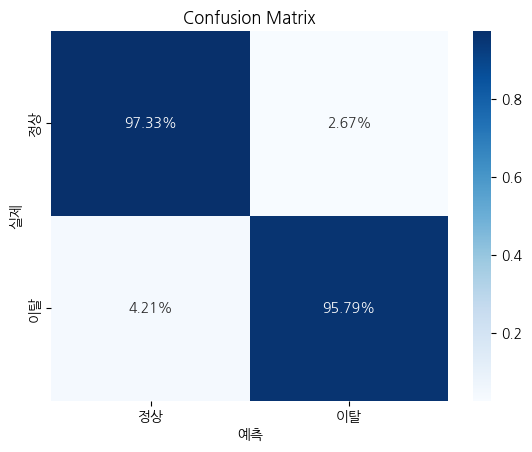

In [25]:
# 혼동 행렬
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_te, best_model.predict(X_te),normalize='true')

sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['정상', '이탈'],
            yticklabels=['정상', '이탈'])
plt.xlabel('예측')
plt.ylabel('실제')
plt.title('Confusion Matrix')
plt.show()

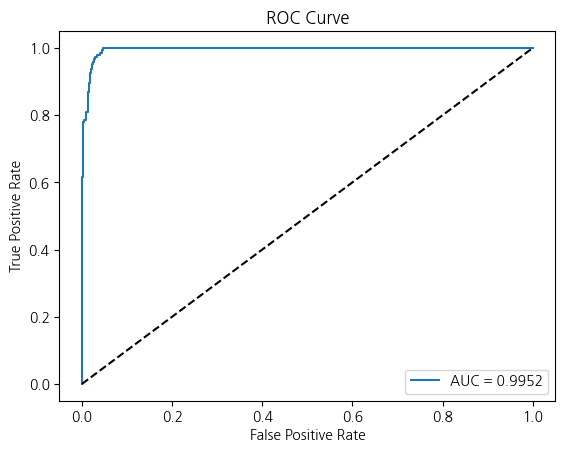

In [26]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_te, best_model.predict_proba(X_te)[:, 1])

plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_te, best_model.predict_proba(X_te)[:,1]):.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

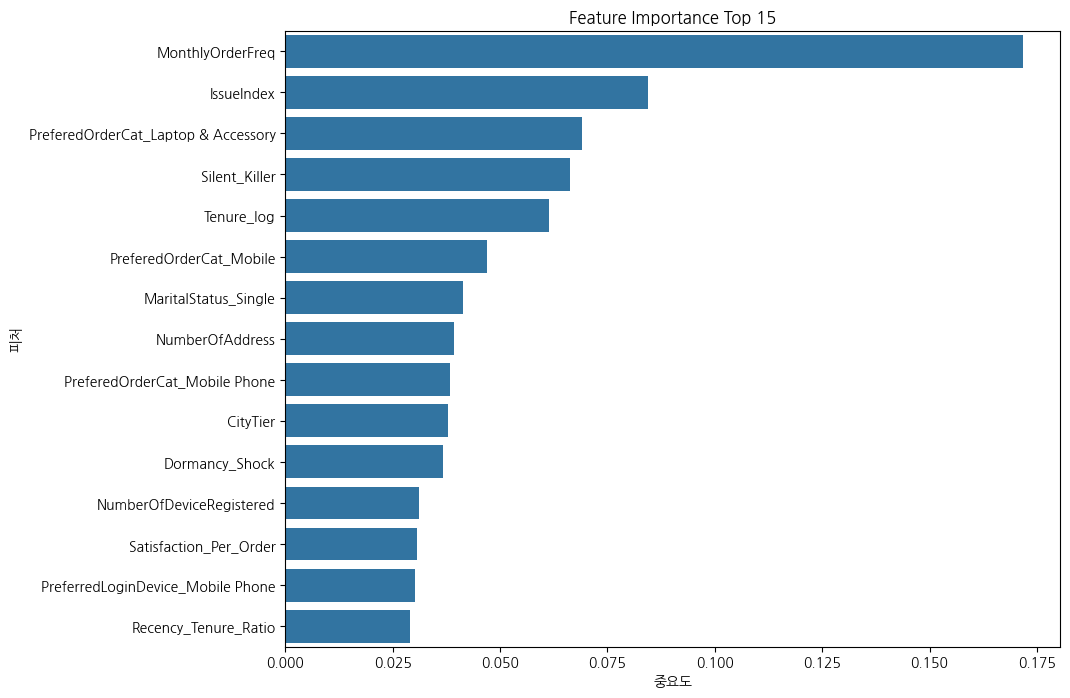

In [28]:
import pandas as pd

feature_importance = pd.DataFrame({
    '피처': X_tr.columns,
    '중요도': best_model.feature_importances_
}).sort_values('중요도', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='중요도', y='피처')
plt.title('Feature Importance Top 15')
plt.show()

# 저장


In [ ]:
# 예측 결과 생성
y_pred = best_model.predict(X_te)
y_proba = best_model.predict_proba(X_te)[:, 1]

# submission 데이터프레임 생성
submission = pd.DataFrame({
    'CustomerID': X_te.index,        # 고객 ID
    'Churn_Actual': y_te.values,     # 실제값
    'Churn_Predicted': y_pred,       # 예측값
    'Churn_Probability': y_proba     # 이탈 확률
})

# 저장 경로
submission_csv = 'C:/dev/project/SKN27-2nd-4TEAM/src/modeling/submission_pcj.csv'

# 저장
submission.to_csv(submission_csv, header=True, index=False)
print(f'저장 완료: {submission_csv}')


저장 완료: C:/dev/project/SKN27-2nd-4TEAM/src/modeling/submission_pcj.csv


#새로운 피쳐를 만든 이유
#그 피쳐들이 진짜 유용했는지

In [29]:
# 진짜로 누수 없는지 검증
# train/test 완전히 다른 데이터로 분리 후 재확인

print(f"X_tr 크기: {X_tr.shape}")
print(f"X_te 크기: {X_te.shape}")

# index 겹치는지 확인
overlap = set(X_tr.index) & set(X_te.index)
print(f"겹치는 index: {len(overlap)}개")  # 0이어야 정상 ✅

X_tr 크기: (4504, 25)
X_te 크기: (1126, 25)
겹치는 index: 0개


In [30]:
# 최적 모델로 평가
best_model = grid_search.best_estimator_
auc_tuned = evaluate_model(best_model, X_tr, y_tr, X_te, y_te, '5단계: 튜닝 모델')

# 이탈률 + AUC 구분해서 출력
y_proba = best_model.predict_proba(X_te)[:, 1]
y_pred  = best_model.predict(X_te)

print("\n=== 이탈률 vs AUC 구분 ===")
print(f"[ 모델 성능 지표 ]")
print(f"  AUC           : {roc_auc_score(y_te, y_proba):.4f}  ← 모델 신뢰도")
print(f"  Accuracy      : {best_model.score(X_te, y_te):.4f}  ← 전체 정확도")
print()
print(f"[ 실제 이탈률 ]")
print(f"  실제 이탈률   : {y_te.mean():.2%}  ← 전체 고객 중 실제 이탈 비율")
print(f"  예측 이탈률   : {y_pred.mean():.2%}  ← 모델이 예측한 이탈 비율")
print()
print(f"[ 이탈 위험 고객 분포 ]")
print(f"  이탈 확률 0~20%  (안전)  : {(y_proba < 0.2).sum()}명  ({(y_proba < 0.2).mean():.2%})")
print(f"  이탈 확률 20~50% (관심)  : {((y_proba >= 0.2) & (y_proba < 0.5)).sum()}명  ({((y_proba >= 0.2) & (y_proba < 0.5)).mean():.2%})")
print(f"  이탈 확률 50~80% (주의)  : {((y_proba >= 0.5) & (y_proba < 0.8)).sum()}명  ({((y_proba >= 0.5) & (y_proba < 0.8)).mean():.2%})")
print(f"  이탈 확률 80~95% (경고)  : {((y_proba >= 0.8) & (y_proba < 0.95)).sum()}명  ({((y_proba >= 0.8) & (y_proba < 0.95)).mean():.2%})")
print(f"  이탈 확률 95~100%(위험)  : {(y_proba >= 0.95).sum()}명  ({(y_proba >= 0.95).mean():.2%})")

[5단계: 튜닝 모델]
  학습 score : 0.9964
  검증 score : 0.9707
  score 차이 : 0.0258 → ✅ 양호
  Train AUC  : 0.9999
  Test  AUC  : 0.9952


=== 이탈률 vs AUC 구분 ===
[ 모델 성능 지표 ]
  AUC           : 0.9952  ← 모델 신뢰도
  Accuracy      : 0.9707  ← 전체 정확도

[ 실제 이탈률 ]
  실제 이탈률   : 16.87%  ← 전체 고객 중 실제 이탈 비율
  예측 이탈률   : 18.38%  ← 모델이 예측한 이탈 비율

[ 이탈 위험 고객 분포 ]
  이탈 확률 0~20%  (안전)  : 855명  (75.93%)
  이탈 확률 20~50% (관심)  : 64명  (5.68%)
  이탈 확률 50~80% (주의)  : 44명  (3.91%)
  이탈 확률 80~95% (경고)  : 68명  (6.04%)
  이탈 확률 95~100%(위험)  : 95명  (8.44%)


C:\Users\Playdata\AppData\Local\Temp\ipykernel_20760\119360249.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_te)


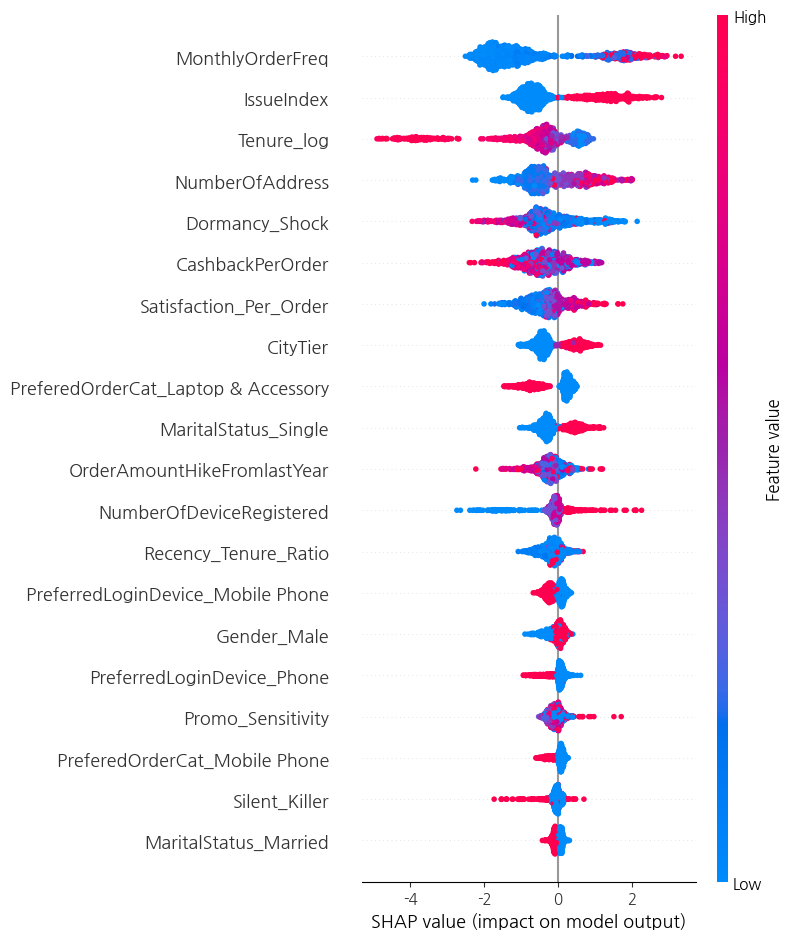

In [31]:
import shap

explainer = shap.TreeExplainer(best_model)

shap_values = explainer.shap_values(X_te)

shap.summary_plot(shap_values, X_te)

In [33]:
# 불만 고객
complain_customers = X_te[X_te['IssueIndex'] == 1]

complain_customers.head()


,CityTier,NumberOfDeviceRegistered,NumberOfAddress,OrderAmountHikeFromlastYear,Tenure_log,Dormancy_Shock,Recency_Tenure_Ratio,MonthlyOrderFreq,IssueIndex,Satisfaction_Per_Order,...,PreferredLoginDevice_Mobile Phone,PreferredLoginDevice_Phone,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,Gender_Male
1969,3,4,8,18.0,3.295837,0.500000,0.269231,0.038462,1,0.500000,...,1,0,0,0,0,0,0,1,0,0
2295,3,3,2,19.0,1.609438,4.285714,1.500000,2.250000,1,0.300000,...,0,0,0,0,0,0,0,1,0,0
3585,1,4,3,13.0,1.791759,0.750000,0.400000,0.400000,1,1.666667,...,1,0,0,1,0,0,0,0,0,1
467,1,3,2,11.0,3.044522,0.000000,0.000000,0.150000,1,0.500000,...,1,0,1,0,0,0,0,0,0,0
1608,3,5,4,12.0,2.995732,2.074074,0.368421,0.368421,1,0.500000,...,1,0,1,0,0,0,0,1,0,0


# Best Model 저장


In [ ]:
import joblib

joblib.dump(best_model, 'best_model_xgboossssttttt-01.pkl')

['best_model_xgboossssttttt-01.pkl']

In [ ]:
pd.concat(
    [
        pd.concat([X_te, y_te], axis=1).assign(split="test"),
    ],
    ignore_index=True,
).to_csv("../../data/XGB_train(X)_train_test_split.csv", index=False, encoding="utf-8-sig")

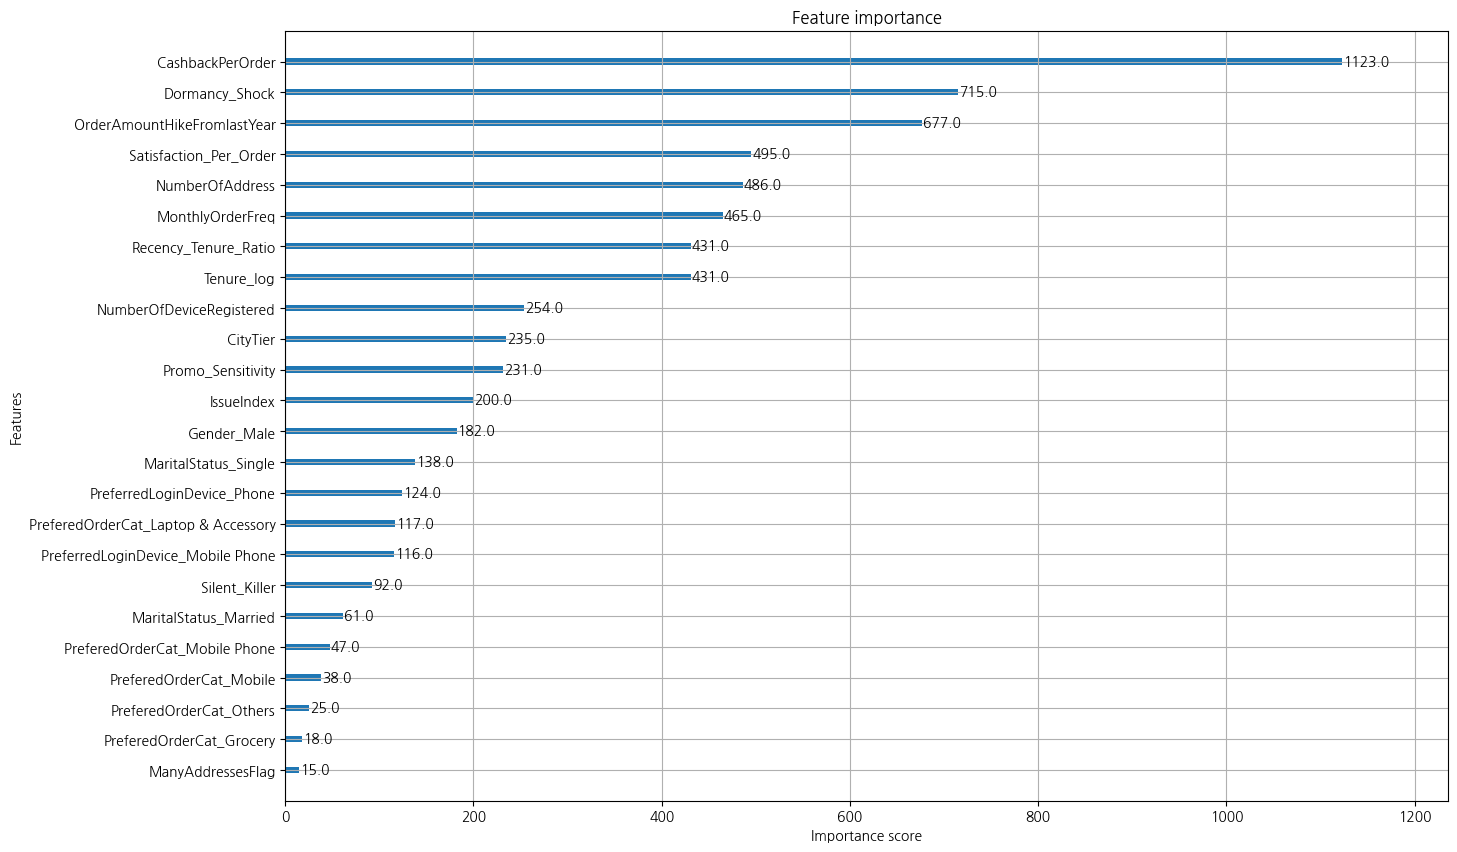

In [34]:
from xgboost import  plot_importance

fig, ax  = plt.subplots(figsize = (15,10))
plot_importance(best_model,ax=ax)
plt.show() 


In [35]:
# 사용 가능한 컬럼들
# Satisfaction_Per_Order ✅ (SatisfactionScore / OrderCount+1)
# CashbackPerOrder ✅
# MonthlyOrderFreq ✅
# OrderAmountHikeFromlastYear ✅ (drop 안됨)

metrics = {
    'MonthlyOrderFreq':   ['MonthlyOrderFreq'],              # 월평균 주문 빈도
    'Cashback':           ['CashbackPerOrder'],              # 주문당 캐시백
    'OrderAmountHike':    ['OrderAmountHikeFromlastYear'],   # 작년 대비 주문량
    'Promo_Sensitivity':  ['Promo_Sensitivity'],             # 쿠폰 민감도
}

print("=== 이탈 vs 유지 고객 지표 비교 ===")
print(f"{'지표':<20} {'이탈 고객':>10} {'유지 고객':>10}")
print("-" * 42)

comparison = {}
for label, cols in metrics.items():
    col = cols[0]
    if col in result_df.columns:
        churn_mean  = churn_df[col].mean()
        retain_mean = retain_df[col].mean()
        comparison[label] = {
            '이탈 고객': round(churn_mean, 2),
            '유지 고객': round(retain_mean, 2)
        }
        print(f"{label:<20} {churn_mean:>10.2f} {retain_mean:>10.2f}")

comparison_df = pd.DataFrame(comparison).T
print("\n=== 웹페이지용 DataFrame ===")
print(comparison_df)

=== 이탈 vs 유지 고객 지표 비교 ===
지표                        이탈 고객      유지 고객
------------------------------------------


NameError: name 'result_df' is not defined

In [36]:
# SHAP 값 계산
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_te)

# 피처명
feature_names = X_te.columns.tolist()

# 고객별 이탈 이유 Top2 추출
result_reasons = []

for i in range(len(X_te)):
    # 해당 고객의 SHAP 값
    shap_vals = shap_values[i]
    
    # 이탈에 기여한 피처만 (양수 값)
    positive_shap = {feature_names[j]: shap_vals[j] 
                     for j in range(len(shap_vals)) 
                     if shap_vals[j] > 0}
    
    # 중요도 순으로 정렬
    sorted_reasons = sorted(positive_shap.items(), 
                           key=lambda x: x[1], reverse=True)
    
    # Top2 추출
    top1 = sorted_reasons[0] if len(sorted_reasons) > 0 else ('없음', 0)
    top2 = sorted_reasons[1] if len(sorted_reasons) > 1 else ('없음', 0)
    
    result_reasons.append({
        'index':          X_te.index[i],
        'Churn_Prob':     round(best_model.predict_proba(X_te)[i][1], 4),
        'Churn_Pred':     best_model.predict(X_te)[i],
        '이탈이유_1순위': top1[0],
        'SHAP_1순위':     round(top1[1], 4),
        '이탈이유_2순위': top2[0],
        'SHAP_2순위':     round(top2[1], 4),
    })

# 데이터프레임으로 변환
reason_df = pd.DataFrame(result_reasons)

# 이탈 예측 고객만 필터링
churn_reason_df = reason_df[reason_df['Churn_Pred'] == 1]

print(f"이탈 예측 고객 수: {len(churn_reason_df)}명")
print(churn_reason_df[['index', 'Churn_Prob', '이탈이유_1순위', 'SHAP_1순위', '이탈이유_2순위', 'SHAP_2순위']].head(10))

이탈 예측 고객 수: 207명
    index  Churn_Prob                이탈이유_1순위  SHAP_1순위  \
11   2125      0.9769        MonthlyOrderFreq    2.2443   
22    958      0.9018          Dormancy_Shock    1.5984   
32   5216      0.9536        MonthlyOrderFreq    1.8826   
41   4377      0.8519        MonthlyOrderFreq    1.8948   
53    932      0.9844        MonthlyOrderFreq    2.2374   
55   2826      0.9720              IssueIndex    2.6520   
59    437      0.9986        MonthlyOrderFreq    2.7368   
64   5582      0.5018              IssueIndex    1.5571   
66   4237      0.5143              IssueIndex    1.7551   
69    808      0.6325  Satisfaction_Per_Order    1.0032   

                  이탈이유_2순위  SHAP_2순위  
11          Dormancy_Shock    1.2675  
22  Satisfaction_Per_Order    1.2559  
32         NumberOfAddress    1.0311  
41    MaritalStatus_Single    1.1209  
53         NumberOfAddress    0.9980  
55         NumberOfAddress    1.2909  
59              IssueIndex    1.7096  
64         NumberOfAd

In [37]:
  # 예측 결과 합치기
result_df = X_te.copy()
result_df['Churn_Prob'] = best_model.predict_proba(X_te)[:, 1]
result_df['Churn_Pred'] = best_model.predict(X_te)

# 고객 등급 분류 함수
def classify_customer(row):
    prob = row['Churn_Prob']
    freq = row['MonthlyOrderFreq']
    
    # 1. VIP: 이탈 확률이 매우 낮고(20% 미만) 주문도 자주 하는 고객
    if prob < 0.2 and freq >= freq_mean:
        return 'VIP'
    
    # 2. At Risk: 모델이 이탈로 예측했거나(50% 이상), 
    #    예측은 안 했어도 확률이 꽤 높으면서(30% 이상) 주문 빈도가 낮은 고객
    elif prob >= 0.5 or (prob >= 0.3 and freq < freq_mean):
        return 'At Risk'
    
    # 3. Active: 위 두 조건에 해당하지 않는 모든 활동 고객 (안정권)
    else:
        return 'Active'

print(f"  이탈 확률 0~20%  (안전)  : {(y_proba < 0.2).sum()}명  ({(y_proba < 0.2).mean():.2%})")
print(f"  이탈 확률 20~50% (관심)  : {((y_proba >= 0.2) & (y_proba < 0.5)).sum()}명  ({((y_proba >= 0.2) & (y_proba < 0.5)).mean():.2%})")
print(f"  이탈 확률 50~80% (주의)  : {((y_proba >= 0.5) & (y_proba < 0.8)).sum()}명  ({((y_proba >= 0.5) & (y_proba < 0.8)).mean():.2%})")
print(f"  이탈 확률 80~95% (경고)  : {((y_proba >= 0.8) & (y_proba < 0.95)).sum()}명  ({((y_proba >= 0.8) & (y_proba < 0.95)).mean():.2%})")
print(f"  이탈 확률 95~100%(위험)  : {(y_proba >= 0.95).sum()}명  ({(y_proba >= 0.95).mean():.2%})")        

freq_mean = result_df['MonthlyOrderFreq'].mean()
result_df['CustomerGrade'] = result_df.apply(classify_customer, axis=1)

# 등급별 수치
grade_counts = result_df['CustomerGrade'].value_counts()
grade_ratio  = result_df['CustomerGrade'].value_counts(normalize=True) * 100

grade_summary = pd.DataFrame({
    '고객 수': grade_counts,
    '비율(%)': grade_ratio.round(2)
})

print("=== 고객 구성 비율 ===")
print(grade_summary)


  이탈 확률 0~20%  (안전)  : 855명  (75.93%)
  이탈 확률 20~50% (관심)  : 64명  (5.68%)
  이탈 확률 50~80% (주의)  : 44명  (3.91%)
  이탈 확률 80~95% (경고)  : 68명  (6.04%)
  이탈 확률 95~100%(위험)  : 95명  (8.44%)
=== 고객 구성 비율 ===
               고객 수  비율(%)
CustomerGrade             
Active          854  75.84
At Risk         235  20.87
VIP              37   3.29


In [38]:
result_df['Churn_Prob']


4006    0.017926
1969    0.000085
4235    0.000539
105     0.000250
2295    0.235802
          ...   
4362    0.186003
2487    0.002619
5063    0.038797
1958    0.004317
1314    0.016352
Name: Churn_Prob, Length: 1126, dtype: float32

In [39]:
# 행 출력 제한을 없애는 설정 (None이 '무제한'을 의미)
pd.set_option('display.max_rows', None)

# 이제 다시 확인해보세요
result_df['Churn_Prob']

4006    0.017926
1969    0.000085
4235    0.000539
105     0.000250
2295    0.235802
4393    0.000461
2951    0.057375
3403    0.003715
3585    0.041268
467     0.014014
2478    0.000907
2125    0.976873
3001    0.010014
4604    0.002460
3094    0.001048
1608    0.009832
1158    0.049445
799     0.008028
150     0.022707
4777    0.002795
1629    0.229500
674     0.000885
958     0.901843
2579    0.005910
669     0.002268
876     0.001345
2334    0.383709
5420    0.004969
4548    0.007610
4497    0.007735
5283    0.012058
4859    0.000739
5216    0.953570
836     0.053094
5028    0.034365
5522    0.004555
4756    0.001177
3499    0.001376
894     0.062394
832     0.018150
3080    0.002251
4377    0.851877
3301    0.048725
156     0.012555
725     0.166930
1841    0.290953
4040    0.018245
3815    0.007011
3339    0.000553
2259    0.000552
1257    0.392490
3171    0.006388
5066    0.000908
932     0.984408
3809    0.007415
2826    0.972027
2561    0.006965
3160    0.028973
4335    0.0011

In [40]:
freq_mean = result_df['MonthlyOrderFreq']
freq_mean

4006      0.470588
1969      0.038462
4235      0.400000
105       0.080000
2295      2.250000
4393      0.083333
2951      0.666667
3403      0.105263
3585      0.400000
467       0.150000
2478      0.062500
2125     10.000000
3001      0.526316
4604      0.318182
3094      1.000000
1608      0.368421
1158      0.250000
799       0.250000
150       0.400000
4777      0.166667
1629     30.000000
674       0.866667
958       0.071429
2579      0.050000
669       0.142857
876       0.100000
2334      0.100000
5420      0.333333
4548      0.125000
4497      1.000000
5283      0.222222
4859      0.307692
5216      2.000000
836       0.125000
5028      2.000000
5522      0.105263
4756      0.333333
3499      1.000000
894       0.111111
832       0.076923
3080      0.235294
4377      2.000000
3301      0.222222
156       0.733333
725       0.200000
1841     10.000000
4040      2.000000
3815      0.666667
3339      0.148148
2259      0.428571
1257      0.500000
3171      0.250000
5066      0.

In [41]:
# 1. 고객별 이탈 확률 계산 및 저장
# [:, 1]은 '이탈(1)'에 대한 확률값만 가져온다는 뜻입니다.
result_df['Churn_Prob'] = best_model.predict_proba(X_te)[:, 1]

# 2. 이탈 확률이 높은 순서대로 정렬 (내림차순)
# CustomerID가 인덱스에 있다면 그대로 보이고, 없다면 컬럼을 포함해 정렬합니다.
churn_ranking = result_df.sort_values(by='Churn_Prob', ascending=False)

# 3. 이탈 위험 상위 10명 출력
print("=== 이탈 위험 고객 TOP 10 ===")
print(churn_ranking[['Churn_Prob']].head(10))

# 4. (팁) 만약 특정 확률(예: 80%) 이상인 고위험군만 보고 싶다면?
high_risk_customers = result_df[result_df['Churn_Prob'] >= 0.8]
print(f"\n이탈 확률 80% 이상 고객 수: {len(high_risk_customers)}명")

=== 이탈 위험 고객 TOP 10 ===
      Churn_Prob
1214    0.999644
338     0.999432
4617    0.999350
2422    0.999127
5346    0.998944
4287    0.998609
437     0.998550
3125    0.998546
807     0.998439
4022    0.998275

이탈 확률 80% 이상 고객 수: 163명


In [42]:
print(result_df.loc[4006, 'Churn_Prob'])

0.017925603


In [43]:
# 1. 모든 행을 다 출력하도록 설정 (None = 제한 없음)
pd.set_option('display.max_rows', None)

# 2. 이탈 확률 계산 (기존 코드와 동일)
result_df['Churn_Prob'] = best_model.predict_proba(X_te)[:, 1]

# 3. 정렬하지 않고 '고객 번호(ID)' 순서대로 모든 수치 출력
# 만약 CustomerID가 컬럼에 있다면 result_df[['CustomerID', 'Churn_Prob']] 로 쓰세요.
print("=== 모든 고객별 이탈 확률 (1:1 확인용) ===")
print(result_df['Churn_Prob'])

=== 모든 고객별 이탈 확률 (1:1 확인용) ===
4006    0.017926
1969    0.000085
4235    0.000539
105     0.000250
2295    0.235802
4393    0.000461
2951    0.057375
3403    0.003715
3585    0.041268
467     0.014014
2478    0.000907
2125    0.976873
3001    0.010014
4604    0.002460
3094    0.001048
1608    0.009832
1158    0.049445
799     0.008028
150     0.022707
4777    0.002795
1629    0.229500
674     0.000885
958     0.901843
2579    0.005910
669     0.002268
876     0.001345
2334    0.383709
5420    0.004969
4548    0.007610
4497    0.007735
5283    0.012058
4859    0.000739
5216    0.953570
836     0.053094
5028    0.034365
5522    0.004555
4756    0.001177
3499    0.001376
894     0.062394
832     0.018150
3080    0.002251
4377    0.851877
3301    0.048725
156     0.012555
725     0.166930
1841    0.290953
4040    0.018245
3815    0.007011
3339    0.000553
2259    0.000552
1257    0.392490
3171    0.006388
5066    0.000908
932     0.984408
3809    0.007415
2826    0.972027
2561    0.006965


In [ ]:
# 아까 화면에서 보셨던, 이탈 확률(Churn_Prob)이 계산된 result_df를 엑셀로 내보냅니다.
# index=True로 설정하면 기존 고객의 고유 행 번호(인덱스)가 유지되어 누구인지 찾기 편합니다.
result_df.to_excel('고객별_이탈확률_결과.xlsx', index=True)

print("엑셀 파일 저장이 완료되었습니다! 작업 폴더를 확인해주세요.")

엑셀 파일 저장이 완료되었습니다! 작업 폴더를 확인해주세요.


In [44]:
# 아래 코드로 진짜 오버피팅인지 확인
print("=== 오버피팅 검증 ===")

# 1. index 겹침 확인 (이미 있음)
overlap = set(X_tr.index) & set(X_te.index)
print(f"index 겹침: {len(overlap)}개 → {'✅ 정상' if len(overlap)==0 else '❌ 누수!'}")

# 2. Train AUC vs Test AUC 차이
train_auc = roc_auc_score(y_tr, best_model.predict_proba(X_tr)[:, 1])
test_auc  = roc_auc_score(y_te, best_model.predict_proba(X_te)[:, 1])
diff = train_auc - test_auc
print(f"Train AUC : {train_auc:.4f}")
print(f"Test  AUC : {test_auc:.4f}")
print(f"차이      : {diff:.4f} → {'✅ 정상' if diff < 0.02 else '⚠️ 오버피팅 의심'}")

# 3. CV AUC와 Test AUC 비교
print(f"CV AUC    : {cv_scores.mean():.4f}")
cv_diff = test_auc - cv_scores.mean()
print(f"Test-CV 차이: {cv_diff:.4f} → {'⚠️ 누수 의심!' if cv_diff > 0.03 else '✅ 정상'}")

=== 오버피팅 검증 ===
index 겹침: 0개 → ✅ 정상
Train AUC : 0.9999
Test  AUC : 0.9952
차이      : 0.0048 → ✅ 정상
CV AUC    : 0.9643
Test-CV 차이: 0.0309 → ⚠️ 누수 의심!


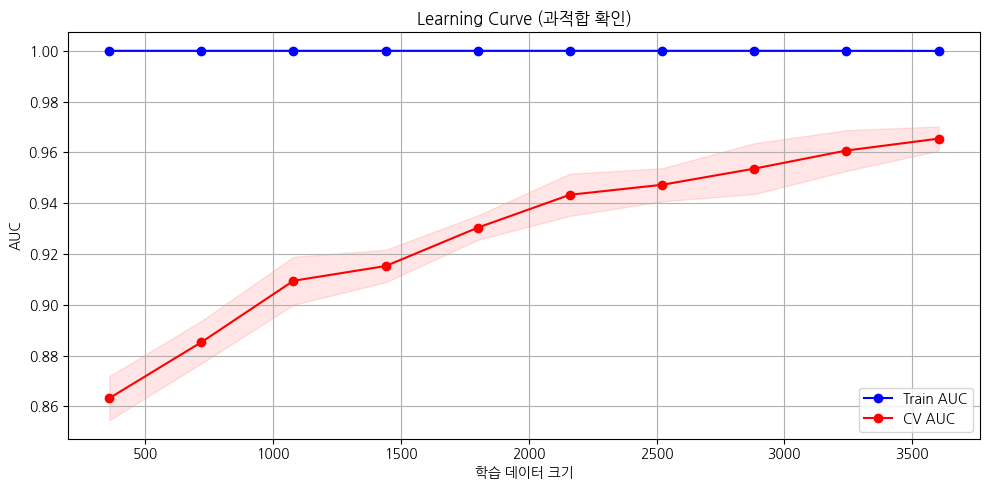

In [45]:


# ── 1. Learning Curve (학습 곡선) ──────────────────
from sklearn.model_selection import learning_curve

set_seed(42)
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_tr, y_tr,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
test_mean  = test_scores.mean(axis=1)
test_std   = test_scores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train AUC')
plt.plot(train_sizes, test_mean,  'o-', color='red',  label='CV AUC')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, test_mean-test_std,   test_mean+test_std,   alpha=0.1, color='red')
plt.xlabel('학습 데이터 크기')
plt.ylabel('AUC')
plt.title('Learning Curve (과적합 확인)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_48816\536761715.py:31: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_48816\536761715.py:31: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_48816\536761715.py:31: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\dev\project\SKN27-2nd-4TEAM\.venv

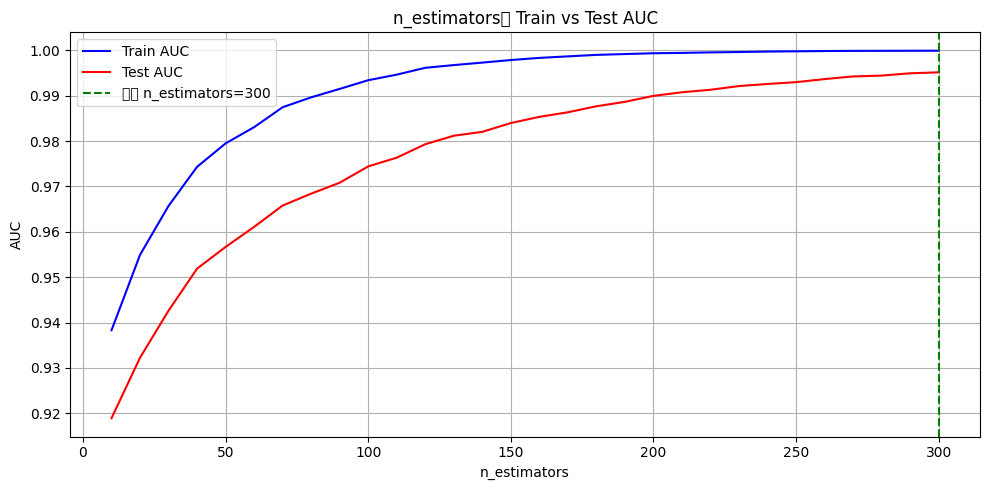

In [ ]:
# ── 2. n_estimators별 Train vs Test AUC ────────────
set_seed(42)
xgb_check = XGBClassifier(
    max_depth=5,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=spw,
    eval_metric='logloss'
)

train_aucs = []
test_aucs  = []
estimator_range = range(10, 310, 10)

for n in estimator_range:
    xgb_check.set_params(n_estimators=n)
    xgb_check.fit(X_tr, y_tr)
    train_aucs.append(roc_auc_score(y_tr, xgb_check.predict_proba(X_tr)[:, 1]))
    test_aucs.append(roc_auc_score(y_te, xgb_check.predict_proba(X_te)[:, 1]))

plt.figure(figsize=(10, 5))
plt.plot(estimator_range, train_aucs, 'b-', label='Train AUC')
plt.plot(estimator_range, test_aucs,  'r-', label='Test AUC')
plt.axvline(x=300, color='green', linestyle='--', label='현재 n_estimators=300')
plt.xlabel('n_estimators')
plt.ylabel('AUC')
plt.title('n_estimators별 Train vs Test AUC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

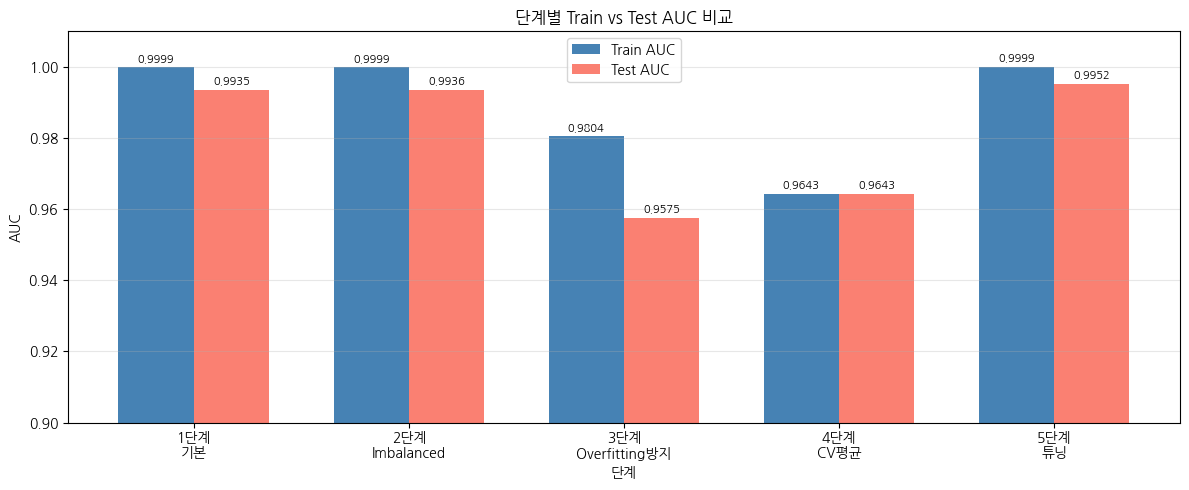

In [46]:
# ── 3. Train vs Test AUC 단계별 비교 ───────────────
stages = ['1단계\n기본', '2단계\nImbalanced', '3단계\nOverfitting방지', '4단계\nCV평균', '5단계\n튜닝']
train_aucs_stages = [
    roc_auc_score(y_tr, xgb_base.predict_proba(X_tr)[:, 1]),
    roc_auc_score(y_tr, xgb_balanced.predict_proba(X_tr)[:, 1]),
    roc_auc_score(y_tr, xgb_reg.predict_proba(X_tr)[:, 1]),
    cv_scores.mean(),
    roc_auc_score(y_tr, best_model.predict_proba(X_tr)[:, 1]),
]
test_aucs_stages = [auc_base, auc_balanced, auc_reg, cv_scores.mean(), auc_tuned]

x = np.arange(len(stages))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, train_aucs_stages, width, label='Train AUC', color='steelblue')
bars2 = ax.bar(x + width/2, test_aucs_stages,  width, label='Test AUC',  color='salmon')

ax.set_xlabel('단계')
ax.set_ylabel('AUC')
ax.set_title('단계별 Train vs Test AUC 비교')
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.legend()
ax.set_ylim(0.9, 1.01)
ax.grid(axis='y', alpha=0.3)

# 값 표시
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

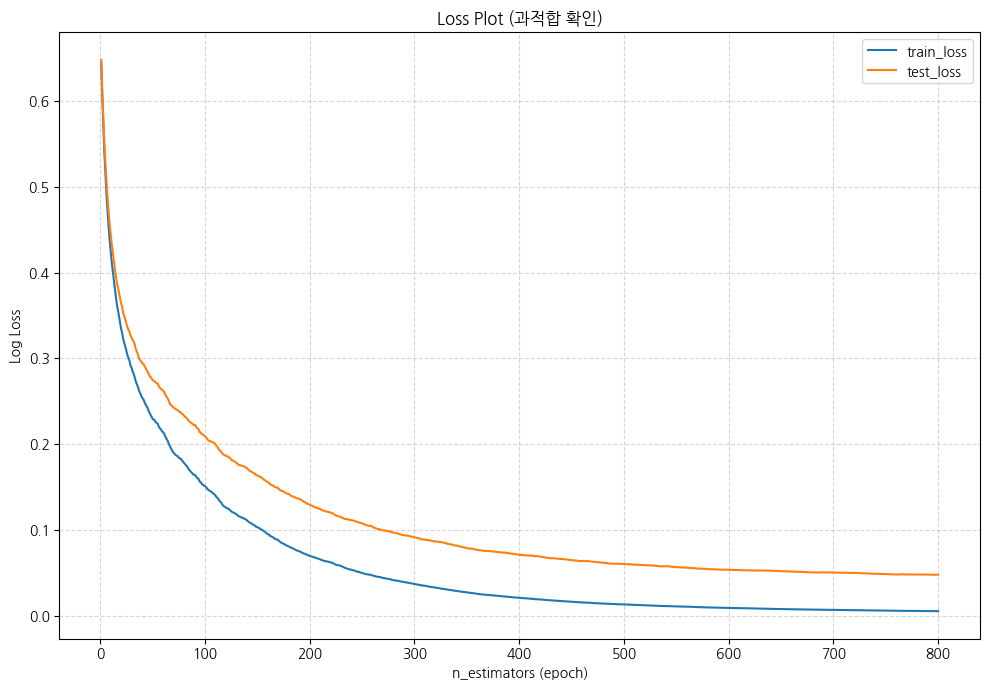

In [47]:
# ── Loss Plot: n_estimators(epoch)별 train_loss vs test_loss ──────────
from sklearn.metrics import log_loss

set_seed(42)
# best_model의 파라미터를 그대로 가져와서 사용
params = best_model.get_params()
params.pop('n_estimators')  # n_estimators는 루프에서 직접 제어

xgb_loss = XGBClassifier(**params)

epoch_lst      = []
train_loss_lst = []
test_loss_lst  = []

for n in range(1, 801):  # 1 ~ 100 estimators (epoch 역할)
    xgb_loss.set_params(n_estimators=n)
    xgb_loss.fit(X_tr, y_tr)

    train_prob = xgb_loss.predict_proba(X_tr)[:, 1]
    test_prob  = xgb_loss.predict_proba(X_te)[:, 1]

    epoch_lst.append(n)
    train_loss_lst.append(log_loss(y_tr, train_prob))
    test_loss_lst.append(log_loss(y_te, test_prob))

# Loss Plot 시각화
plt.figure(figsize=(10, 7))
plt.plot(epoch_lst, train_loss_lst, label='train_loss')
plt.plot(epoch_lst, test_loss_lst,  label='test_loss')
plt.xlabel('n_estimators (epoch)')
plt.ylabel('Log Loss')
plt.title('Loss Plot (과적합 확인)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
C:\Users\Playdata\AppData\Local\Temp\ipykernel_48816\3674039135.py:95: UserWarning: Glyph 44277 (\N{HANGUL SYLLABLE GONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_48816\3674039135.py:95: UserWarning: Glyph 48177 (\N{HANGUL SYLLABLE BAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_48816\3674039135.py:95: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_48816\3674039135.py:95: UserWarning: Glyph 52649 (\N{HANGUL SYLLABLE CUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata\AppData\Local\Temp\ipykernel_48816\3674039135.py:95: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Playdata

지표                             이탈 고객      유지 고객       차이
-------------------------------------------------------
공백기 충격도 (클수록 위험)               2.325      1.706   +0.619
가입기간 대비 공백기 비중                 9.057      2.166   +6.891
월평균 주문 빈도                      7.380      1.164   +6.216
주문당 만족도                        1.145      0.971   +0.174
주문당 캐시백                       51.265     54.687   -3.423
쿠폰 민감도                         0.397      0.401   -0.004
조용한 이탈자 비율                     0.089      0.235   -0.146
정체된 충성고객 비율                    0.000      0.030   -0.030


findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
findfont: Font family 'AppleGothic' not found.
c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\dev\project\SKN27-2nd-4TEAM\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_

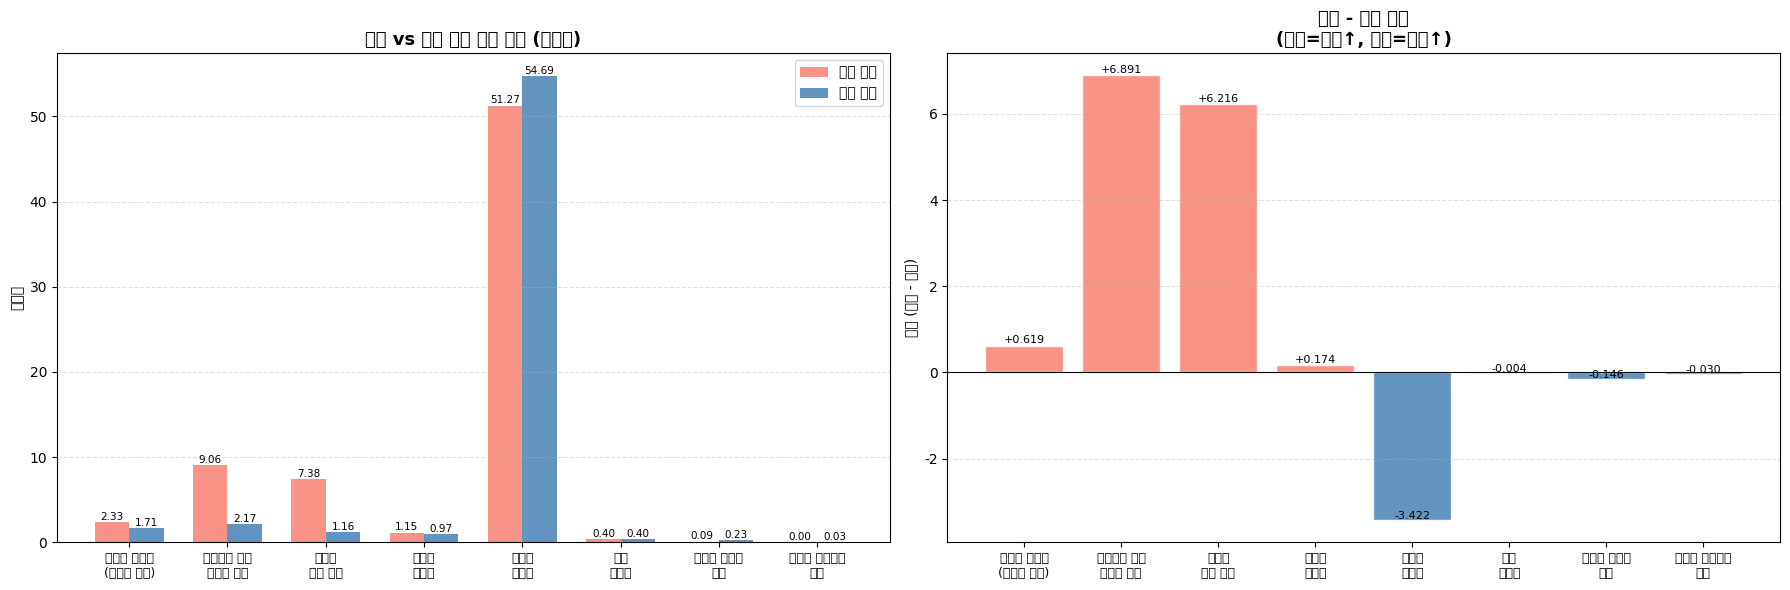

In [ ]:
# ── 이탈 vs 유지 고객 지표 비교 (재구성) ──────────────────────────────

# 1. result_df 재생성 (X_te 기반)
result_df = X_te.copy()
result_df['Churn_Prob'] = best_model.predict_proba(X_te)[:, 1]
result_df['Churn_Pred'] = best_model.predict(X_te)
result_df['Churn_Actual'] = y_te.values

# 이탈 / 유지 분리 (실제값 기준)
churn_df  = result_df[result_df['Churn_Actual'] == 1]
retain_df = result_df[result_df['Churn_Actual'] == 0]

# 2. 비교할 피처 선정 (features.py 기반, 이탈 설계 피처 위주)
compare_features = {
    'Dormancy_Shock':       '공백기 충격도\n(클수록 위험)',
    'Recency_Tenure_Ratio': '가입기간 대비\n공백기 비중',
    'MonthlyOrderFreq':     '월평균\n주문 빈도',
    'Satisfaction_Per_Order': '주문당\n만족도',
    'CashbackPerOrder':     '주문당\n캐시백',
    'Promo_Sensitivity':    '쿠폰\n민감도',
    'Silent_Killer':        '조용한 이탈자\n비율',
    'Stagnant_Loyal':       '정체된 충성고객\n비율',
}

# 3. 수치 비교표 출력
print("=" * 55)
print(f"{'지표':<25} {'이탈 고객':>10} {'유지 고객':>10} {'차이':>8}")
print("-" * 55)

rows = []
for col, label in compare_features.items():
    if col in result_df.columns:
        c_mean = churn_df[col].mean()
        r_mean = retain_df[col].mean()
        diff   = c_mean - r_mean
        label_clean = label.replace('\n', ' ')
        print(f"{label_clean:<25} {c_mean:>10.3f} {r_mean:>10.3f} {diff:>+8.3f}")
        rows.append({'피처': label, '이탈 고객': round(c_mean, 3), '유지 고객': round(r_mean, 3)})

print("=" * 55)


matplotlib.rcParams['font.family'] = 'AppleGothic'  # Mac
# matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # Windows

valid_rows = [r for r in rows if r['피처'].replace('\n',' ') in 
              [label.replace('\n',' ') for label in compare_features.values()]]

labels     = [r['피처'] for r in rows]
churn_vals = [r['이탈 고객'] for r in rows]
retain_vals= [r['유지 고객'] for r in rows]

x     = np.arange(len(labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── 왼쪽: 절대값 비교 막대그래프
ax1 = axes[0]
bars1 = ax1.bar(x - width/2, churn_vals,  width, label='이탈 고객', color='salmon',   alpha=0.85)
bars2 = ax1.bar(x + width/2, retain_vals, width, label='유지 고객', color='steelblue', alpha=0.85)

ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=9)
ax1.set_title('이탈 vs 유지 고객 지표 비교 (절대값)', fontsize=13, fontweight='bold')
ax1.set_ylabel('평균값')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7.5)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7.5)

# ── 오른쪽: 이탈-유지 차이 (양수=이탈이 높음, 음수=유지가 높음)
ax2 = axes[1]
diffs  = [c - r for c, r in zip(churn_vals, retain_vals)]
colors = ['salmon' if d > 0 else 'steelblue' for d in diffs]

bars3 = ax2.bar(x, diffs, color=colors, alpha=0.85, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, fontsize=9)
ax2.set_title('이탈 - 유지 차이\n(빨강=이탈↑, 파랑=유지↑)', fontsize=13, fontweight='bold')
ax2.set_ylabel('차이 (이탈 - 유지)')
ax2.grid(axis='y', linestyle='--', alpha=0.4)

for bar, d in zip(bars3, diffs):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.01 if d >= 0 else -0.03),
             f'{d:+.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# 누수 여부 빠른 확인
print(f"index 겹침: {len(set(X_tr.index) & set(X_te.index))}개")  # 반드시 0

index 겹침: 0개


In [ ]:
# train/test AUC 차이 확인
train_auc = roc_auc_score(y_tr, best_model.predict_proba(X_tr)[:,1])
test_auc  = roc_auc_score(y_te, best_model.predict_proba(X_te)[:,1])
print(f"Train AUC: {train_auc:.4f}")
print(f"Test  AUC: {test_auc:.4f}")
print(f"차이: {train_auc - test_auc:.4f} → 0.05 이상이면 과적합 의심")


Train AUC: 0.9999
Test  AUC: 0.9952
차이: 0.0048 → 0.05 이상이면 과적합 의심


In [ ]:
# CV AUC와 test AUC 비교 (가장 중요!)
print(f"CV AUC:   {cv_scores.mean():.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"차이: {test_auc - cv_scores.mean():.4f} → 0.03 이상이면 누수 의심 🚨")

CV AUC:   0.9643
Test AUC: 0.9952
차이: 0.0309 → 0.03 이상이면 누수 의심 🚨


In [48]:
# 1. 모델이 예측한 이탈자(확률 0.5 이상) 필터링
# result_df에 Churn_Prob가 들어있다고 가정합니다.
predicted_churners = result_df[result_df['Churn_Prob'] >= 0.5]

# 2. 인원 수 계산
total_count = len(result_df)
churner_count = len(predicted_churners)

# 3. 확률(비중) 계산
churn_rate = (churner_count / total_count) * 100

print(f"전체 인원: {total_count}명")
print(f"이탈 예측 인원(확률 0.5 이상): {churner_count}명")
print(f"예측 이탈률: {churn_rate:.2f}%")

# 4. (추가) 만약 이 이탈 예측자들 중에서 IssueIndex가 1인 사람의 비중도 보고 싶다면?
issue_and_churn = predicted_churners[predicted_churners['IssueIndex'] == 1]
print(f"이탈 예측자 중 불만 제기자 수: {len(issue_and_churn)}명")

전체 인원: 1126명
이탈 예측 인원(확률 0.5 이상): 207명
예측 이탈률: 18.38%
이탈 예측자 중 불만 제기자 수: 115명


In [49]:
# 모델이 예측한 전체 평균 이탈 확률
predicted_avg_prob = result_df['Churn_Prob'].mean()

print(f"모델 예측 평균 이탈 확률: {predicted_avg_prob:.2f}")

모델 예측 평균 이탈 확률: 0.20


In [50]:
# ── 고객 등급 분류 (5단계) ──────────────────────────────

result_df = X_te.copy()
result_df['Churn_Prob'] = best_model.predict_proba(X_te)[:, 1]
result_df['Churn_Pred'] = best_model.predict(X_te)

freq_mean = result_df['MonthlyOrderFreq'].mean()

def classify_customer_v2(row):
    prob = row['Churn_Prob']
    freq = row['MonthlyOrderFreq']

    if prob < 0.1 and freq >= freq_mean:
        return 'VIP'          # 이탈 확률 매우 낮고 주문도 활발
    elif prob < 0.2:
        return 'Platinum'     # 이탈 확률 낮음
    elif prob < 0.5:
        return 'Gold'         # 관심 필요
    elif prob < 0.8:
        return 'Silver'       # 이탈 위험
    else:
        return 'Risk'         # 고위험

result_df['CustomerGrade'] = result_df.apply(classify_customer_v2, axis=1)

# ── 등급별 수치 출력 (이탈 확률처럼) ──────────────────────
grade_order = ['VIP', 'Platinum', 'Gold', 'Silver', 'Risk']
grade_emoji = {'VIP': '👑', 'Platinum': '💎', 'Gold': '🥇', 'Silver': '🥈', 'Risk': '🚨'}

print("=" * 50)
print("  고객 등급 분포")
print("=" * 50)
for grade in grade_order:
    count = (result_df['CustomerGrade'] == grade).sum()
    ratio = (result_df['CustomerGrade'] == grade).mean() * 100
    emoji = grade_emoji[grade]
    print(f"  {emoji} {grade:<10} : {count:>4}명  ({ratio:.2f}%)")

print()

# ── 등급별 평균 이탈 확률 추가 출력 ────────────────────────
print("== 등급별 평균 이탈 확률 ==")
grade_summary = result_df.groupby('CustomerGrade').agg(
    고객수=('Churn_Prob', 'count'),
    평균이탈확률=('Churn_Prob', 'mean'),
    비율=('Churn_Prob', lambda x: f"{len(x)/len(result_df)*100:.2f}%")
).reindex(grade_order)

grade_summary['평균이탈확률'] = grade_summary['평균이탈확률'].map(lambda x: f"{x:.2%}")
print(grade_summary)

  고객 등급 분포
  👑 VIP        :   30명  (2.66%)
  💎 Platinum   :  825명  (73.27%)
  🥇 Gold       :   64명  (5.68%)
  🥈 Silver     :   44명  (3.91%)
  🚨 Risk       :  163명  (14.48%)

== 등급별 평균 이탈 확률 ==
               고객수  평균이탈확률      비율
CustomerGrade                     
VIP             30   3.74%   2.66%
Platinum       825   2.06%  73.27%
Gold            64  33.47%   5.68%
Silver          44  64.35%   3.91%
Risk           163  93.87%  14.48%


In [51]:
# ── CSV용 test 데이터 구성 ──────────────────────────────────

# 1. 이탈 확률 & 예측값 (실제 best_model 사용)
churn_prob = best_model.predict_proba(X_te)[:, 1]
churn_pred = best_model.predict(X_te)

# 2. 고객 등급 분류 함수
freq_mean = X_te['MonthlyOrderFreq'].mean()

def classify_grade(prob, freq):
    if prob < 0.1 and freq >= freq_mean:
        return 'VIP'
    elif prob < 0.2:
        return 'Platinum'
    elif prob < 0.5:
        return 'Gold'
    elif prob < 0.8:
        return 'Silver'
    else:
        return 'Risk'

def classify_risk(prob):
    if prob < 0.2:   return '안전'
    elif prob < 0.5: return '관심'
    elif prob < 0.8: return '주의'
    elif prob < 0.95:return '위험'
    else:            return '고위험'

# 3. 고객 리스트용 CSV (Streamlit 화면 표시용)
customer_list = pd.DataFrame({
    'CustomerID'               : [f'C{str(i+1).zfill(4)}' for i in range(len(X_te))],
    'Churn_Actual'             : y_te.values,
    'Churn_Pred'               : churn_pred,
    'Churn_Prob'               : churn_prob.round(4),
    'RiskLevel'                : [classify_risk(p) for p in churn_prob],
    'CustomerGrade'            : [classify_grade(p, f) for p, f in zip(churn_prob, X_te['MonthlyOrderFreq'])],
    'MonthlyOrderFreq'         : X_te['MonthlyOrderFreq'].round(4),
    'Dormancy_Shock'           : X_te['Dormancy_Shock'].round(4),
    'Recency_Tenure_Ratio'     : X_te['Recency_Tenure_Ratio'].round(4),
    'CashbackPerOrder'         : X_te['CashbackPerOrder'].round(2),
    'Promo_Sensitivity'        : X_te['Promo_Sensitivity'].round(4),
    'Satisfaction_Per_Order'   : X_te['Satisfaction_Per_Order'].round(4),
    'IssueIndex'               : X_te['IssueIndex'].values,
    'Silent_Killer'            : X_te['Silent_Killer'].values,
    'Stagnant_Loyal'           : X_te['Stagnant_Loyal'].values,
    'OrderAmountHikeFromlastYear': X_te['OrderAmountHikeFromlastYear'].round(2),
    'Tenure_log'               : X_te['Tenure_log'].round(4),
    'NumberOfAddress'          : X_te['NumberOfAddress'].values,
})

# 4. 모델 예측용 전체 피처 CSV (Streamlit 모델 연결용)
customer_full = X_te.copy().reset_index(drop=True)
customer_full.insert(0, 'CustomerID', customer_list['CustomerID'])
customer_full['Churn_Actual']   = y_te.values
customer_full['Churn_Prob']     = churn_prob.round(4)
customer_full['Churn_Pred']     = churn_pred
customer_full['RiskLevel']      = customer_list['RiskLevel'].values
customer_full['CustomerGrade']  = customer_list['CustomerGrade'].values

# 5. 저장
customer_list.to_csv('customer_list.csv', index=False, encoding='utf-8-sig')
customer_full.to_csv('customer_full.csv', index=False, encoding='utf-8-sig')

print(f"✅ customer_list.csv 저장 완료: {customer_list.shape}")
print(f"✅ customer_full.csv 저장 완료: {customer_full.shape}")
print()
print("== 등급 분포 ==")
grade_order = ['VIP', 'Platinum', 'Gold', 'Silver', 'Risk']
grade_emoji = {'VIP': '👑', 'Platinum': '💎', 'Gold': '🥇', 'Silver': '🥈', 'Risk': '🚨'}
for grade in grade_order:
    count = (customer_list['CustomerGrade'] == grade).sum()
    ratio = count / len(customer_list) * 100
    print(f"  {grade_emoji[grade]} {grade:<10}: {count:>4}명  ({ratio:.2f}%)")

✅ customer_list.csv 저장 완료: (1126, 18)
✅ customer_full.csv 저장 완료: (1126, 31)

== 등급 분포 ==
  👑 VIP       :   30명  (2.66%)
  💎 Platinum  :  825명  (73.27%)
  🥇 Gold      :   64명  (5.68%)
  🥈 Silver    :   44명  (3.91%)
  🚨 Risk      :  163명  (14.48%)
